## Codigo para benchmark con random forest

In [17]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [2]:
ELO_MIN = 1000 
ELO_MAX = 3322
ELO_MEAN = 1851.1
ELO_STD = 495.3  
ELO_MEDIAN = 1839.0
ELO_Q1 = 1442.0
ELO_Q3 = 2230.0
ELO_IQR = ELO_Q3 - ELO_Q1

In [3]:
class ChessDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, norm_type="standard"):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        
        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0], -1)
            
        self.X = torch.tensor(X_filtrado, dtype=torch.float32)
        
        if norm_type == "minmax":
            y_seleccionada = datos['y_minmax']
        elif norm_type == "robust":
            y_seleccionada = datos['y_robust']
        elif norm_type == "raw":
            y_seleccionada = datos['y_raw']
        else:
            y_seleccionada = datos['y_standard'] # Por defecto
            
        # Lo pasamos a tensor y le damos forma (N, 1)
        self.y = torch.tensor(y_seleccionada, dtype=torch.float32).view(-1, 1)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
plies = [21]
ply = plies
flatten = 1
norm = "raw" # "standard", "minmax", "robust", "raw"
crit = "mse" # "huber", "mse"
print("Cargando datasets a la memoria...")

train_ds = ChessDataset("../data/generado/only_enc/train.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
val_ds = ChessDataset("../data/generado/only_enc/val.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
test_ds = ChessDataset("../data/generado/only_enc/test.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)


train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

Cargando datasets a la memoria...


In [5]:
def extraer_datos_a_numpy(dataloader):
    X_list, y_list = [], []
    for batch_X, batch_y in dataloader:
        # Aplanamos conservando solo la dimensión del batch: (Batch, 832)
        X_list.append(batch_X.view(batch_X.size(0), -1).numpy())
        y_list.append(batch_y.numpy())
    
    return np.vstack(X_list), np.concatenate(y_list)

In [6]:
print("Extrayendo tensores a matrices NumPy...")
X_train_np, y_train_np = extraer_datos_a_numpy(train_loader)
X_test_np, y_test_np = extraer_datos_a_numpy(test_loader)
y_train_np = y_train_np.ravel()
y_test_np = y_test_np.ravel()

Extrayendo tensores a matrices NumPy...


In [7]:
print(f"Entrenando Random Forest con {X_train_np.shape[1]} variables...")
# n_estimators=100 es el estándar. Si tu PC se queda sin RAM, bájalo a 50 o usa max_depth=20
rf_modelo = RandomForestRegressor(
    n_estimators=100, 
    n_jobs=-1,          # Usa todos los hilos de tu CPU
    random_state=SEED,    # Para que el experimento sea reproducible en tu tesis
    max_depth=None      # Deja que los árboles crezcan lo necesario
)

rf_modelo.fit(X_train_np, y_train_np)

Entrenando Random Forest con 832 variables...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",37
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [8]:
print("Calculando predicciones...")
y_pred_rf = rf_modelo.predict(X_test_np)

Calculando predicciones...


In [9]:
errores_absolutos = np.abs(y_test_np - y_pred_rf)
errores_cuadraticos = (y_test_np - y_pred_rf) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)

print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

MAE (Error Absoluto Medio):   296.3 puntos de Elo
Mediana del Error:            248.4 puntos de Elo
RMSE (Raíz Error Cuadrático): 372.9 puntos de Elo
Peor equivocación del modelo: 1499.5 puntos de Elo


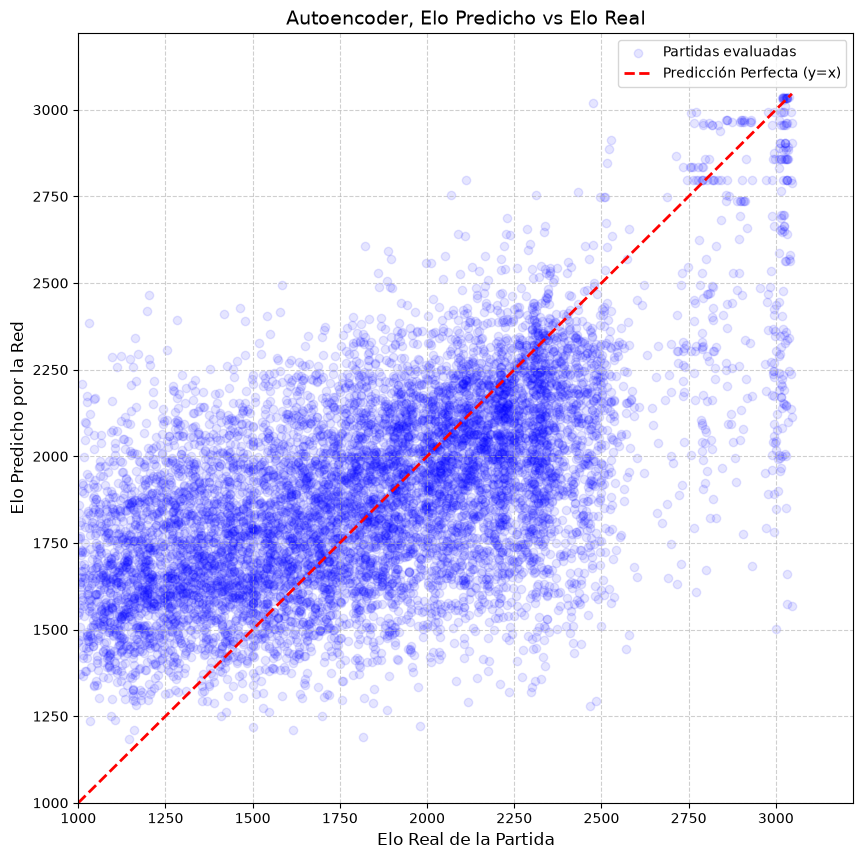

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(y_test_np, y_pred_rf, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(y_test_np), min(y_pred_rf))
max_val = max(max(y_test_np), max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Random Forest, Elo Predicho vs Elo Real', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()

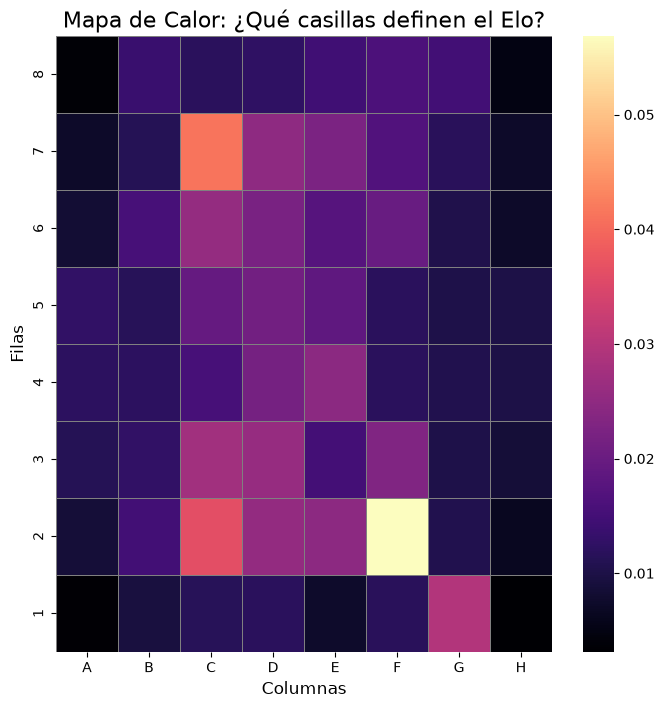

In [15]:


# 1. Extraer las importancias del Random Forest (array de 832)
importancias_planas = rf_modelo.feature_importances_

# 2. Reconstruir la forma matricial original (13 canales, 8 filas, 8 columnas)
importancias_matriz = importancias_planas.reshape(13, 8, 8)

# 3. Sumar la importancia a través de los 13 canales
# Esto nos dice qué "casilla" es importante, sin importar qué pieza esté ahí
importancia_por_casilla = importancias_matriz.sum(axis=0)

# 4. Dibujar el Mapa de Calor
plt.figure(figsize=(8, 8))

# Usamos seaborn para un mapa de calor elegante
# Nota: Dependiendo de cómo armaste tu tablero, puede que necesites invertir el eje Y
sns.heatmap(importancia_por_casilla, 
            cmap='magma',          # Colores de frío (oscuro) a calor (brillante)
            annot=False,           # Pon True si quieres ver los valores numéricos exactos
            xticklabels=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
            yticklabels=['8', '7', '6', '5', '4', '3', '2', '1'],
            linewidths=0.5, 
            linecolor='gray')

plt.title('Mapa de Calor: ¿Qué casillas definen el Elo?', fontsize=16)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)
plt.show()

### Viendo que un modelo funcionó, hago un random search de Random Forests

In [22]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'max_features': ['sqrt', 'log2'], 
    'min_samples_leaf': [1, 2, 4, 10],
    'min_samples_split': [2, 5, 10]
}
X_val_np, y_val_np = extraer_datos_a_numpy(val_loader)
y_val_np = y_val_np.ravel()
X_combined = np.vstack((X_train_np, X_val_np))
y_combined = np.concatenate((y_train_np, y_val_np))
test_fold = np.concatenate([
    np.full(X_train_np.shape[0], -1),
    np.full(X_val_np.shape[0], 0)
])
ps = PredefinedSplit(test_fold)

In [23]:
rf_base = RandomForestRegressor(random_state=SEED)

# 3. Configurar la búsqueda aleatoria
# n_iter=15 significa que probará 15 combinaciones al azar del menú (para no tardar días)
# cv=3 divide tu train set en 3 pedazos para validar sin usar el test set real
# n_jobs=-1 usa el 100% de tu CPU
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=15, 
    cv=ps,
    verbose=2, # Te irá imprimiendo el progreso
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_absolute_error' # Optimiza buscando el mejor MAE
)

In [24]:
# Puede tardar
print("Buscando el mejor Random Forest...")
rf_random.fit(X_combined, y_combined) # Recuerda que los y_train deben tener .ravel()

print("\n=== MEJOR CONFIGURACIÓN ENCONTRADA ===")
print(rf_random.best_params_)
mejor_rf = rf_random.best_estimator_
y_pred_mejor_rf = mejor_rf.predict(X_test_np)

Buscando el mejor Random Forest...
Fitting 1 folds for each of 15 candidates, totalling 15 fits

=== MEJOR CONFIGURACIÓN ENCONTRADA ===
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [ ]:
errores_absolutos = np.abs(y_test_np - y_pred_mejor_rf)
errores_cuadraticos = (y_test_np - y_pred_mejor_rf) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)

print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(y_test_np, y_pred_mejor_rf, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(y_test_np), min(y_pred_rf))
max_val = max(max(y_test_np), max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Random Forest, Elo Predicho vs Elo Real', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()